Imports and Data Loading

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

csv_path = '../results/hybrid_benchmark_results.csv'
df = pd.read_csv(csv_path)

display(df.head())

,M,ef_construction,batch_size,candidates_per_query,beam_search_ef,build_time_sec,throughput_vec_sec,recall_1,recall_10
0,16,100,1000,3000,1,69.2647,14437.4,0.9319,0.908480
1,16,100,1000,3000,1,70.4184,14200.8,0.9347,0.907700
2,16,100,1000,3000,1,67.1848,14884.3,0.9312,0.906239
3,16,100,1000,3000,10,60.7900,16450.1,0.9841,0.967827
4,16,100,1000,3000,10,63.3181,15793.3,0.9847,0.967989


Pareto Frontier

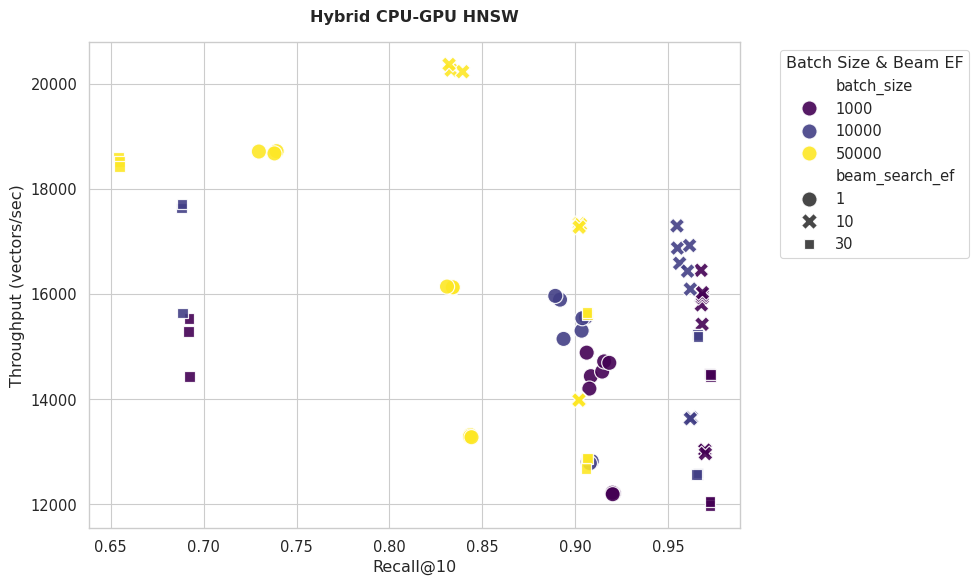

In [4]:
plt.figure(figsize=(10, 6))

# Plot Recall vs Throughput
sns.scatterplot(
    data=df, 
    x='recall_10', 
    y='throughput_vec_sec', 
    hue='batch_size', 
    style='beam_search_ef',
    palette='viridis',
    s=120, # Marker size
    alpha=0.9
)

plt.title('Hybrid CPU-GPU HNSW', weight='bold', pad=15)
plt.xlabel('Recall@10')
plt.ylabel('Throughput (vectors/sec)')

# Move legend outside the plot so it doesn't cover data
plt.legend(title='Batch Size & Beam EF', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../results/pareto_frontier.png', bbox_inches='tight') 
plt.show()

Beam Search Ablation Study

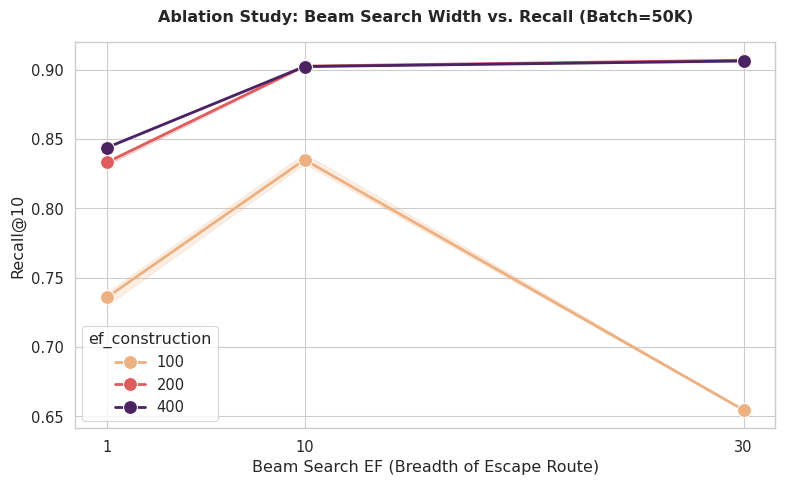

In [3]:
# Filter for the 50k batch size to isolate the beam search impact
df_50k = df[df['batch_size'] == 50000].copy()

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_50k,
    x='beam_search_ef',
    y='recall_10',
    hue='ef_construction',
    marker='o',
    palette='flare',
    linewidth=2,
    markersize=10
)

plt.title('Ablation Study: Beam Search Width vs. Recall (Batch=50K)', weight='bold', pad=15)
plt.xlabel('Beam Search EF (Breadth of Escape Route)')
plt.ylabel('Recall@10')
plt.xticks([1, 10, 30]) # Force exact x-axis ticks
plt.tight_layout()
plt.savefig('../results/ablation_beam_search.pdf', bbox_inches='tight')
plt.show()

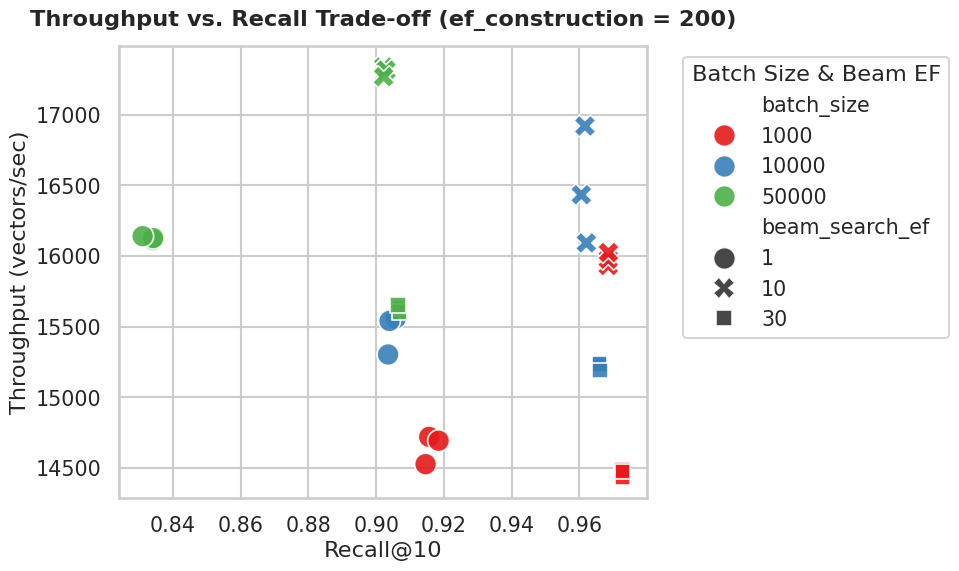

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a larger context specifically for PowerPoint slides
sns.set_theme(style="whitegrid", context="talk", font_scale=0.9)

# Load data (assuming you have your new averaged data, but this works for the old too)
df = pd.read_csv('../results/hybrid_benchmark_results.csv')

# --- GRAPH 1: The Clean Trade-off (Fixed ef_construction) ---
# Isolate a single graph density so the trends are obvious
df_ef200 = df[df['ef_construction'] == 200].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_ef200, 
    x='recall_10', 
    y='throughput_vec_sec', 
    hue='batch_size', 
    style='beam_search_ef',
    palette='Set1', # Stronger colors for projectors
    s=250,          # Massive markers for visibility
    alpha=0.9
)

plt.title('Throughput vs. Recall Trade-off (ef_construction = 200)', weight='bold', pad=15)
plt.xlabel('Recall@10')
plt.ylabel('Throughput (vectors/sec)')

# Clean up the legend
plt.legend(title='Batch Size & Beam EF', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig('../results/slide_tradeoff_ef200.pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_21672/2879581688.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


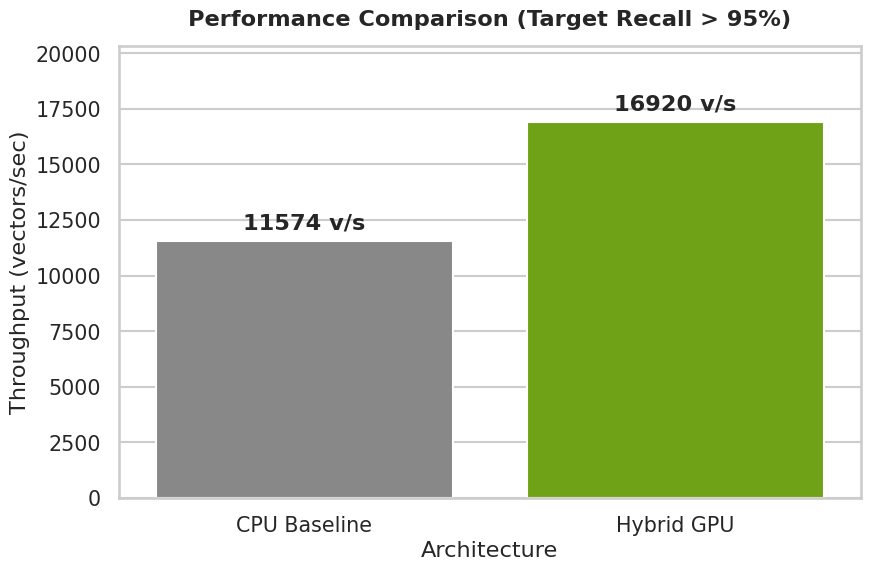

In [7]:
# --- GRAPH 2: Hybrid vs. Multi-core CPU Baseline ---
# You will manually input your baseline result here once your C++ script finishes
cpu_baseline_throughput = 11574  # REPLACE WITH YOUR ACTUAL PARALLEL CPU RESULT
cpu_baseline_recall = 0.99     # REPLACE WITH ACTUAL CPU RECALL

# Find our "Optimal" Hybrid Run from the data
optimal_hybrid = df_ef200[(df_ef200['batch_size'] == 10000) & (df_ef200['beam_search_ef'] == 10)].iloc[0]

# Prepare data for a clean bar chart
comparison_data = pd.DataFrame({
    'Architecture': ['CPU Baseline', 'Hybrid GPU'],
    'Throughput (vec/sec)': [cpu_baseline_throughput, optimal_hybrid['throughput_vec_sec']],
    'Recall@10': [cpu_baseline_recall, optimal_hybrid['recall_10']]
})

fig, ax1 = plt.subplots(figsize=(9, 6))

# Plot Throughput as Bars
sns.barplot(
    data=comparison_data, 
    x='Architecture', 
    y='Throughput (vec/sec)', 
    palette=['#888888', '#76b900'], # Grey for CPU, NVIDIA Green for GPU
    ax=ax1
)

# Add text labels on top of the bars
for i, val in enumerate(comparison_data['Throughput (vec/sec)']):
    ax1.text(i, val + 500, f'{int(val)} v/s', horizontalalignment='center', weight='bold')

plt.title('Performance Comparison (Target Recall > 95%)', weight='bold', pad=15)
plt.ylabel('Throughput (vectors/sec)')
plt.ylim(0, max(comparison_data['Throughput (vec/sec)']) * 1.2) # Give headroom for labels

plt.tight_layout()
plt.savefig('../results/baseline_comparison.png')
plt.show()

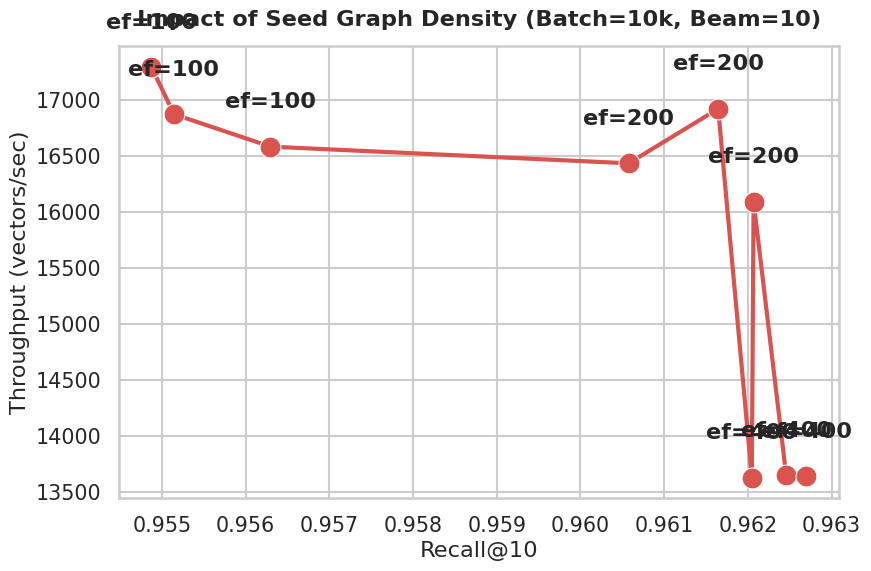

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the same styling
sns.set_theme(style="whitegrid", context="talk", font_scale=0.9)

# Assuming 'df' is your loaded results DataFrame
# 1. Isolate to just your optimal hybrid configuration
df_ef_sweep = df[(df['batch_size'] == 10000) & (df['beam_search_ef'] == 10)].copy()

# Sort by ef_construction so the line draws logically
df_ef_sweep = df_ef_sweep.sort_values('ef_construction')

plt.figure(figsize=(9, 6))

# 2. Draw a line plot with markers to show the direct progression
sns.lineplot(
    data=df_ef_sweep, 
    x='recall_10', 
    y='throughput_vec_sec', 
    marker='o',
    markersize=15,
    linewidth=3,
    color='#d9534f' # A nice distinct red/coral
)

# 3. Add text labels directly above the dots so it's instantly readable
for i in range(df_ef_sweep.shape[0]):
    plt.text(
        x=df_ef_sweep['recall_10'].iloc[i], 
        y=df_ef_sweep['throughput_vec_sec'].iloc[i] + (df_ef_sweep['throughput_vec_sec'].max() * 0.02), # slight offset
        s=f"ef={int(df_ef_sweep['ef_construction'].iloc[i])}", 
        horizontalalignment='center', 
        weight='bold'
    )
plt.title('Impact of Seed Graph Density (Batch=10k, Beam=10)', weight='bold', pad=15)

plt.xlabel('Recall@10')
plt.ylabel('Throughput (vectors/sec)')

plt.tight_layout()
plt.savefig('../results/appendix_ef_impact.pdf', bbox_inches='tight') 
plt.show()